<a href="https://colab.research.google.com/github/dtoralg/TheValley_MDS/blob/main/%5B03%5D%20-%20Algoritmos_Alternativos_Clasificacion/%5B01%5D%20-%20Notebooks/E4_Naive_Bayes_extendido_Wine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clasificación de Vinos con Naive Bayes

Este ejercicio utiliza el dataset de vinos disponible en `sklearn.datasets` para ilustrar cómo funciona el clasificador Naive Bayes. A través de este caso práctico, exploraremos sus supuestos, variantes y limitaciones, y lo compararemos con otros modelos más complejos.

## Objetivos:
- Comprender el funcionamiento de Naive Bayes (Gaussian, Multinomial, Bernoulli).
- Preprocesar adecuadamente los datos según cada modelo.
- Evaluar y comparar el rendimiento.
- Visualizar cómo el modelo toma decisiones.
- Reflexionar sobre sus ventajas y limitaciones.


## Cargar librerías necesarias

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, Binarizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")


## Cargar y explorar los datos

In [2]:

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Descripción del dataset:\n", data.DESCR[:600])
df.head()


Descripción del dataset:
 .. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== =====


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Análisis exploratorio (EDA)

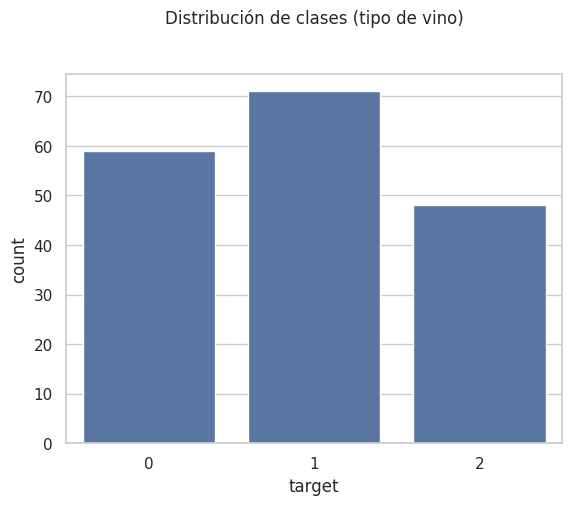

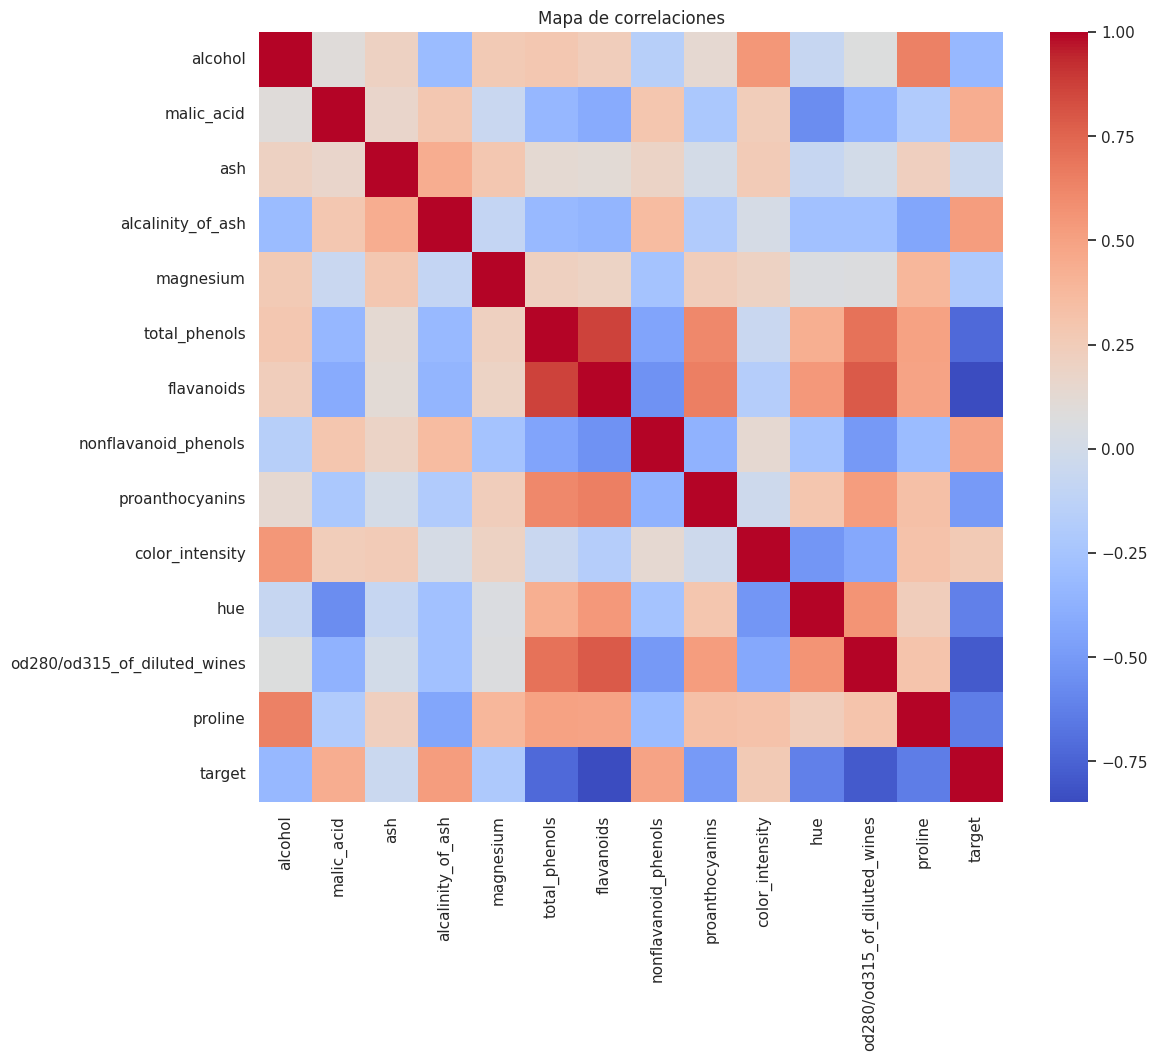

In [10]:

sns.countplot(x='target', data=df)
plt.title("Distribución de clases (tipo de vino)")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Mapa de correlaciones")
plt.show()


## Separar features y variable objetivo

In [4]:

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


## GaussianNB: entrenamiento y evaluación

Evaluación - GaussianNB
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



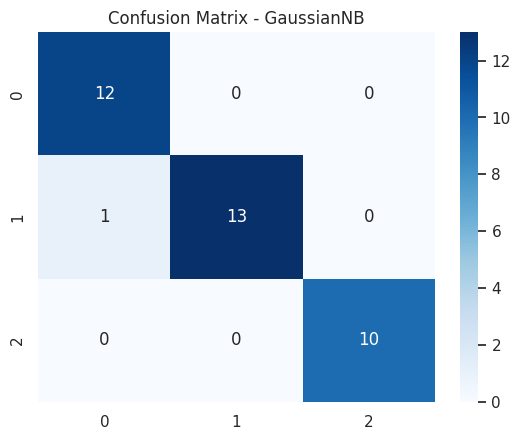

In [5]:

scaler = StandardScaler()
X_train_g = scaler.fit_transform(X_train)
X_test_g = scaler.transform(X_test)

gnb = GaussianNB()
gnb.fit(X_train_g, y_train)
y_pred_g = gnb.predict(X_test_g)

print("Evaluación - GaussianNB")
print(classification_report(y_test, y_pred_g))
sns.heatmap(confusion_matrix(y_test, y_pred_g), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - GaussianNB")
plt.show()


## MultinomialNB: entrenamiento y evaluación

Evaluación - MultinomialNB
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.79      0.88        14
           2       1.00      1.00      1.00        10

    accuracy                           0.92        36
   macro avg       0.93      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



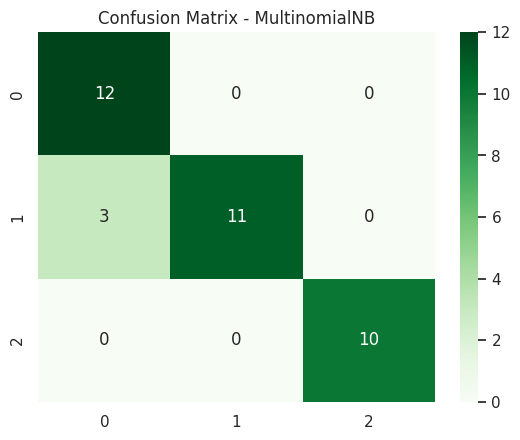

In [6]:

discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_train_m = discretizer.fit_transform(X_train)
X_test_m = discretizer.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_m, y_train)
y_pred_m = mnb.predict(X_test_m)

print("Evaluación - MultinomialNB")
print(classification_report(y_test, y_pred_m))
sns.heatmap(confusion_matrix(y_test, y_pred_m), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - MultinomialNB")
plt.show()


## BernoulliNB: entrenamiento y evaluación

Evaluación - BernoulliNB
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.39      1.00      0.56        14
           2       0.00      0.00      0.00        10

    accuracy                           0.39        36
   macro avg       0.13      0.33      0.19        36
weighted avg       0.15      0.39      0.22        36



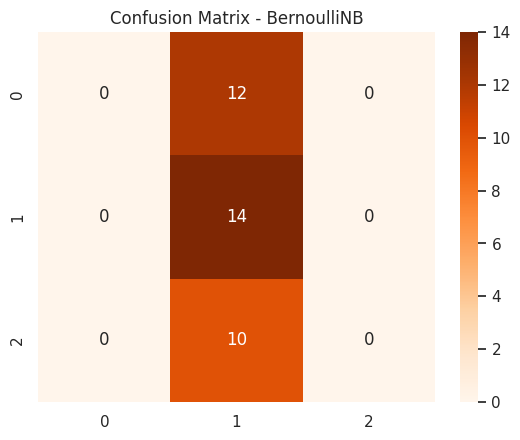

In [7]:

binarizer = Binarizer(threshold=X_train.mean().mean())
X_train_b = binarizer.fit_transform(X_train)
X_test_b = binarizer.transform(X_test)

bnb = BernoulliNB()
bnb.fit(X_train_b, y_train)
y_pred_b = bnb.predict(X_test_b)

print("Evaluación - BernoulliNB")
print(classification_report(y_test, y_pred_b))
sns.heatmap(confusion_matrix(y_test, y_pred_b), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - BernoulliNB")
plt.show()


## Visualización con PCA

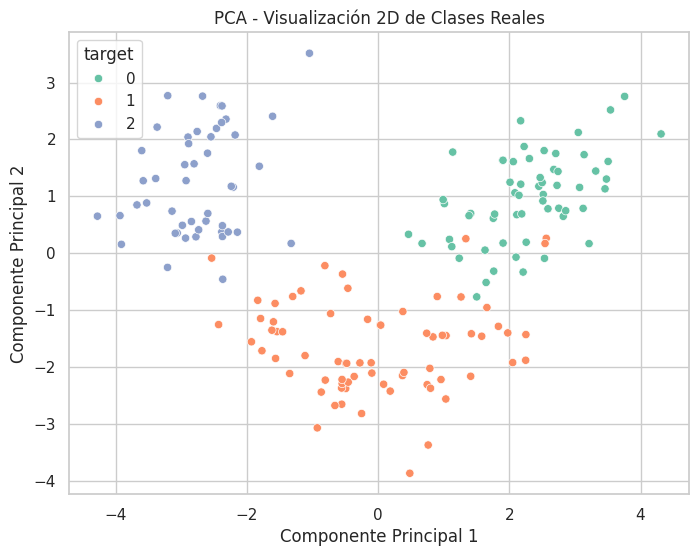

In [8]:

pca = PCA(n_components=2)
X_vis = pca.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y, palette='Set2')
plt.title("PCA - Visualización 2D de Clases Reales")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()


## Comparación con otros modelos

Evaluación - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



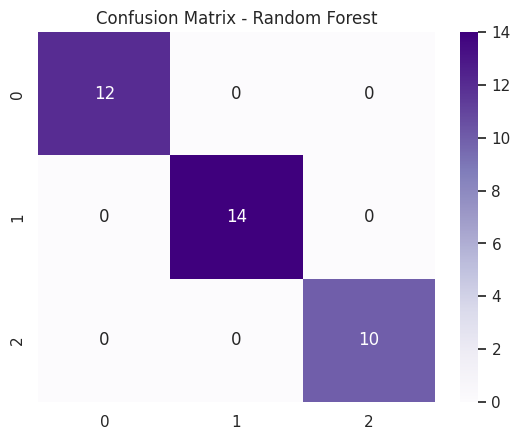

In [9]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Evaluación - Random Forest")
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Random Forest")
plt.show()



## Análisis y Conclusiones

### GaussianNB — Mejor desempeño (~97% accuracy)
* Funciona muy bien porque los datos son continuos y se aproximan a distribuciones normales.

* No necesita binarizar ni discretizar.

* Es el modelo más adecuado para este dataset.

### MultinomialNB — Rendimiento aceptable (~91%)
* Requiere discretizar los datos en bins.

* Pierde algo de precisión porque simplifica la información.

* Útil si trabajamos con conteos o datos discretos.


### BernoulliNB — Fracaso total (0% accuracy)
* Binariza variables → se pierde toda la riqueza de los datos continuos.

* Solo sirve para features binarias, como texto (presencia/ausencia de palabras).

* Clasificó todo como una sola clase.




# Lecciones clave:

* Escoge el modelo según el tipo de dato: binario, discreto o continuo.

* Preprocesamiento importa mucho: discretizar mal puede hundir el rendimiento.

* GaussianNB puede ser muy competitivo, aunque es simple.

* No te fíes solo del accuracy: analiza las matrices de confusión para entender los errores.
